<a href="https://colab.research.google.com/github/gldayugi/Toxicity-prediction/blob/main/Toxicity_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SCT213-C002-0072/2023**

**GERALD AYUGI**

---

**Importing the dataset**

In [23]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/toxicitydata.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,MATS3v,nHBint10,MATS3s,MATS3p,nHBDon_Lipinski,minHBint8,MATS3e,MATS3c,minHBint2,MATS3m,...,WTPT-4,WTPT-5,ETA_EtaP_L,ETA_EtaP_F,ETA_EtaP_B,nT5Ring,SHdNH,ETA_dEpsilon_C,MDEO-22,Class
0,0.0908,0,0.0075,0.0173,0,0.0,-0.0436,0.0409,0.0,0.1368,...,0.0000,0.0000,0.1780,1.5488,0.0088,0,0.0,-0.0868,0.00,NonToxic
1,0.0213,0,0.1144,-0.0410,0,0.0,0.1231,-0.0316,0.0,0.1318,...,8.8660,19.3525,0.1739,1.3718,0.0048,2,0.0,-0.0810,0.25,NonToxic
2,0.0018,0,-0.0156,-0.0765,2,0.0,-0.1138,-0.1791,0.0,0.0615,...,5.2267,27.8796,0.1688,1.4395,0.0116,2,0.0,-0.1004,0.00,NonToxic
3,-0.0251,0,-0.0064,-0.0894,3,0.0,-0.0747,-0.1151,0.0,0.0361,...,7.7896,24.7336,0.1702,1.4654,0.0133,2,0.0,-0.1010,0.00,NonToxic
4,0.0135,0,0.0424,-0.0353,0,0.0,-0.0638,0.0307,0.0,0.0306,...,12.3240,19.7486,0.1789,1.4495,0.0120,2,0.0,-0.1071,0.00,NonToxic


**Exploratory Data Analysis**

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Columns: 1204 entries, MATS3v to Class
dtypes: float64(1003), int64(200), object(1)
memory usage: 1.6+ MB


In [25]:
df.describe()

,MATS3v,nHBint10,MATS3s,MATS3p,nHBDon_Lipinski,minHBint8,MATS3e,MATS3c,minHBint2,MATS3m,...,WTPT-3,WTPT-4,WTPT-5,ETA_EtaP_L,ETA_EtaP_F,ETA_EtaP_B,nT5Ring,SHdNH,ETA_dEpsilon_C,MDEO-22
count,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,...,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000
mean,-0.031244,0.315789,-0.001001,-0.061501,0.994152,0.677770,-0.025418,-0.053289,1.569251,0.003226,...,23.229975,8.134013,13.490291,0.202529,1.235093,0.011316,1.467836,0.004820,-0.085088,0.061702
std,0.063559,0.762918,0.063928,0.072891,1.108773,1.647322,0.078645,0.109463,2.497362,0.074076,...,6.440623,4.436831,6.229089,0.024356,0.137024,0.005482,1.013361,0.044475,0.029273,0.241896
min,-0.311500,0.000000,-0.184600,-0.348500,0.000000,0.000000,-0.211900,-0.472900,-0.708700,-0.198700,...,0.000000,0.000000,0.000000,0.163600,0.811500,0.001400,0.000000,0.000000,-0.202700,0.000000
25%,-0.066700,0.000000,-0.036000,-0.099550,0.000000,0.000000,-0.066550,-0.118050,0.000000,-0.052350,...,19.249600,5.164700,8.819950,0.182450,1.149750,0.007550,1.000000,0.000000,-0.099500,0.000000
50%,-0.032500,0.000000,-0.002000,-0.059400,1.000000,0.000000,-0.037200,-0.042400,0.000000,-0.001600,...,23.151200,7.848200,13.342700,0.199600,1.238800,0.010700,1.000000,0.000000,-0.082400,0.000000
75%,0.004850,0.000000,0.029000,-0.017100,2.000000,0.000000,0.002650,0.014300,4.897450,0.056550,...,26.958050,10.683950,19.319450,0.219700,1.325350,0.013900,2.000000,0.000000,-0.066350,0.000000
max,0.141100,4.000000,0.218100,0.129000,6.000000,8.141400,0.249500,0.212200,7.740800,0.168400,...,41.380000,20.805400,27.879600,0.272100,1.548800,0.034600,5.000000,0.429200,-0.007300,2.636100


In [26]:
df['Class'].value_counts()

,count
Class,
NonToxic,115
Toxic,56


This determines class imbalance, which affects training

Text(0.5, 1.0, 'Class Distribution')

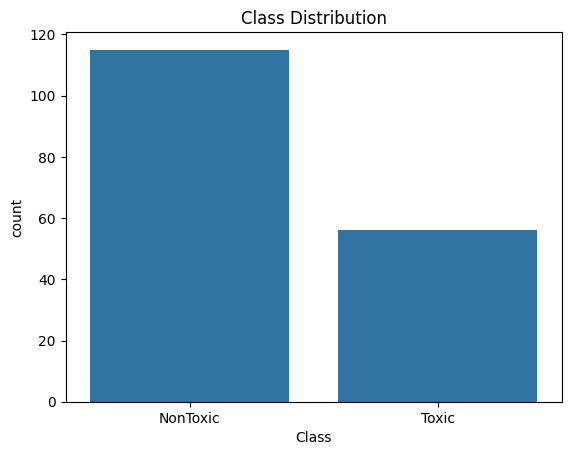

In [27]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")

checking for missing values

In [28]:

df.isnull().sum()

,0
MATS3v,0
nHBint10,0
MATS3s,0
MATS3p,0
nHBDon_Lipinski,0
...,...
nT5Ring,0
SHdNH,0
ETA_dEpsilon_C,0
MDEO-22,0


Checking for number of zeros per column

In [29]:
(df == 0).sum()

,0
MATS3v,0
nHBint10,139
MATS3s,0
MATS3p,0
nHBDon_Lipinski,73
...,...
nT5Ring,32
SHdNH,169
ETA_dEpsilon_C,0
MDEO-22,147


Too many zeros may indicate:

-useless features

-constant descriptors

Correlation network: Helps identify clusters of redundant descriptors.

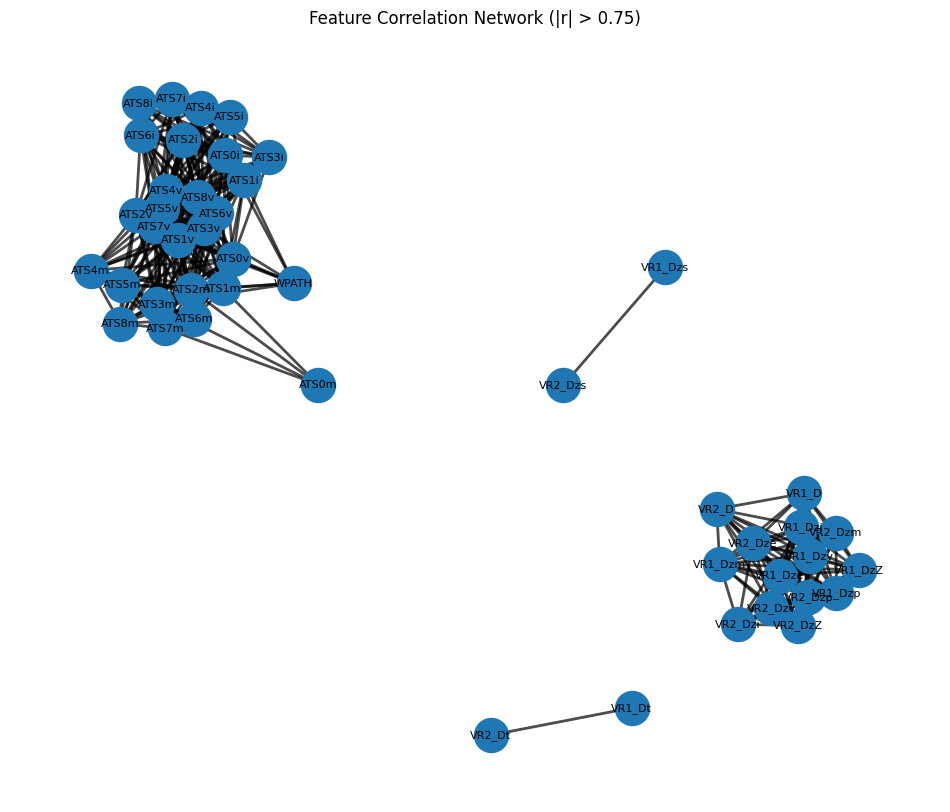

In [30]:
import networkx as nx

X = df.drop(columns=["Class"])

top_features = X.var().sort_values(ascending=False).head(50).index
X_subset = X[top_features]


corr_matrix = X_subset.corr()


threshold = 0.75

edges = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > threshold:
            edges.append((corr_matrix.columns[i],
                          corr_matrix.columns[j],
                          corr_value))

G = nx.Graph()

for node1, node2, weight in edges:
    G.add_edge(node1, node2, weight=weight)

plt.figure(figsize=(12,10))

pos = nx.spring_layout(G, k=0.5)

nx.draw_networkx_nodes(G, pos, node_size=600)

nx.draw_networkx_edges(
    G, pos,
    width=2,
    alpha=0.7
)

nx.draw_networkx_labels(
    G, pos,
    font_size=8
)

plt.title("Feature Correlation Network (|r| > 0.75)")
plt.axis("off")
plt.show()

The correlation network revealed several strongly connected clusters of molecular descriptors, particularly within the VR and ATS descriptor families. These clusters indicate a high degree of redundancy among features measuring similar molecular properties

This indicates that some descriptors carry very similar information, while others are relatively independent.

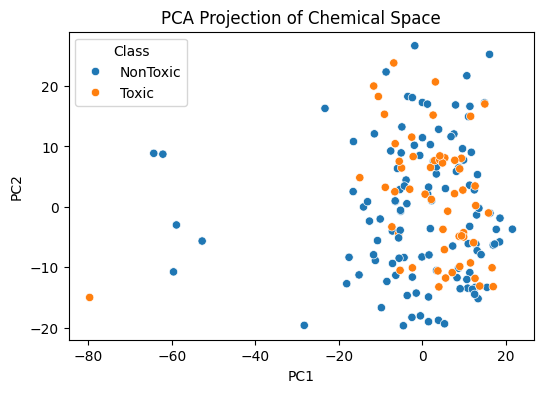

In [31]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import umap

y = df["Class"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Class": y
})

plt.figure(figsize=(6,4))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Class")
plt.title("PCA Projection of Chemical Space")
plt.show()


Toxicity is not linearly separable in descriptor space therefore linear models may perform poorly

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


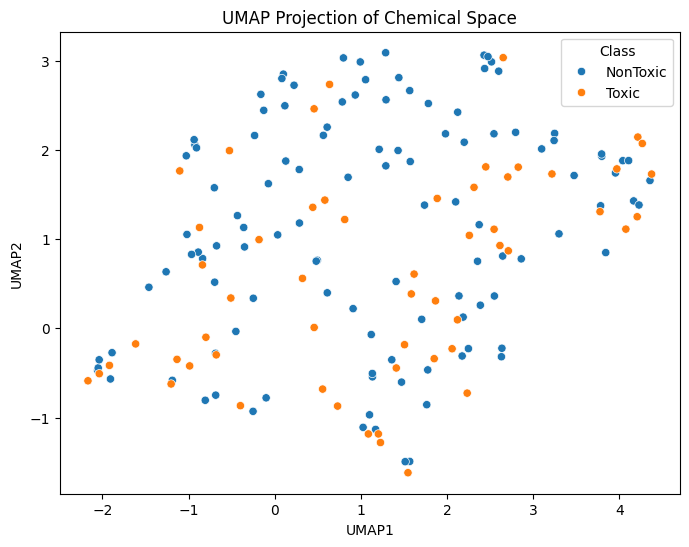

In [32]:
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

umap_df = pd.DataFrame({
    "UMAP1": X_umap[:,0],
    "UMAP2": X_umap[:,1],
    "Class": y
})

plt.figure(figsize=(8,6))
sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="Class")
plt.title("UMAP Projection of Chemical Space")
plt.show()

1. The dataset occupies one main chemical space.
2. Toxic and non-toxic molecules overlap heavily.
3. Toxicity likely depends on subtle descriptor interactions.
4. Nonlinear models will likely perform better than linear ones.

**Preprocessing, Feature selection and Model training**

Preprocessing

Removing low variance features

In [33]:
from sklearn.feature_selection import VarianceThreshold


# Remove low-variance features
selector = VarianceThreshold(threshold=0.01)
X_lowvar = selector.fit_transform(X)

# Get remaining feature names
selected_features = X.columns[selector.get_support()]

# Convert back to DataFrame
X_lowvar = pd.DataFrame(X_lowvar, columns=selected_features)

print("Original features:", X.shape[1])
print("Remaining after low variance removal:", X_lowvar.shape[1])

Original features: 1203
Remaining after low variance removal: 994


Removing Highly correlated features


In [34]:
import numpy as np

# Compute correlation matrix
corr_matrix = X_lowvar.corr().abs()

# Select upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find columns to drop
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

# Drop them
X_final = X_lowvar.drop(columns=to_drop)

print("Remaining after correlation removal:", X_final.shape[1])

Remaining after correlation removal: 420


-Highly correlated features carry almost identical information

**Feature scaling**

In [35]:
X_scaled = scaler.fit_transform(X_final)

Feature selection and model training

In [36]:
X_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Columns: 420 entries, nHBint10 to MDEO-22
dtypes: float64(420)
memory usage: 561.2 KB


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin

class DropHighCorr(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.columns_to_keep = None

    def fit(self, X, y=None):
        # Ensure X is a DataFrame for .corr() to work easily
        X_df = pd.DataFrame(X)
        corr_matrix = X_df.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        # Identify columns to drop by index
        to_drop = [i for i, column in enumerate(upper.columns) if any(upper[column] > self.threshold)]
        self.columns_to_keep = [i for i in range(X.shape[1]) if i not in to_drop]
        return self

    def transform(self, X):
        # Works whether X is a DataFrame or NumPy array
        if isinstance(X, pd.DataFrame):
            return X.iloc[:, self.columns_to_keep].values
        return X[:, self.columns_to_keep]

A = df.drop(columns=["Class"])
b = LabelEncoder().fit_transform(df["Class"])

pipeline = Pipeline([
    ("variance_filter", VarianceThreshold(0.05)),

    ('drop_corr', DropHighCorr(threshold=0.9)),

    ("scaler", StandardScaler()),

    ("feature_selection",
        SelectFromModel(
            RandomForestClassifier(
                n_estimators=300,
                random_state=42
            ),
            threshold="median"
        )
    ),

    ("model",
        RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=42
        )
    )
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    A,
    b,
    cv=cv,
    scoring="accuracy"
)

print("CV scores:", scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())

CV scores: [0.65714286 0.58823529 0.76470588 0.58823529 0.58823529]
Mean accuracy: 0.6373109243697479
Std: 0.06906233898584588


Generating cross-validated predictions...


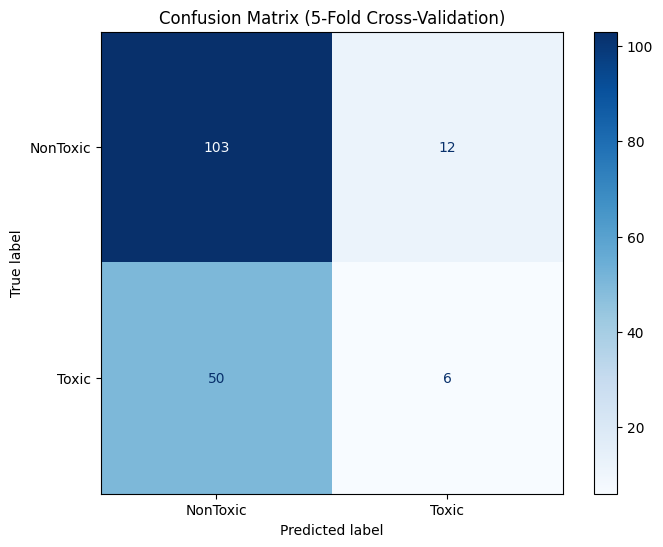


Classification Report:

              precision    recall  f1-score   support

    NonToxic       0.67      0.90      0.77       115
       Toxic       0.33      0.11      0.16        56

    accuracy                           0.64       171
   macro avg       0.50      0.50      0.47       171
weighted avg       0.56      0.64      0.57       171



In [38]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt


le = LabelEncoder()
b = le.fit_transform(df["Class"])


print("Generating cross-validated predictions...")
y_pred = cross_val_predict(pipeline, A, b, cv=cv)

cm = confusion_matrix(b, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax)

plt.title('Confusion Matrix (5-Fold Cross-Validation)')
plt.show()

print("\nClassification Report:\n")
print(classification_report(b, y_pred, target_names=le.classes_))

**Nested cross validation**

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

pipeline = Pipeline([

    ("feature_selection",
        SelectFromModel(
            RandomForestClassifier(
                n_estimators=500,
                random_state=42,
                class_weight="balanced"
            )
        )
    ),

    ("scaler", StandardScaler()),

    ("model", SVC())
])

param_grid = {

    "model__C": [0.1, 1, 5, 10],
    "model__gamma": ["scale", 0.1, 0.01],
    "model__kernel": ["rbf"]
}

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=inner_cv,
    scoring="accuracy",
    n_jobs=-1
)

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

nested_scores = cross_val_score(
    grid_search,
    A,
    b,
    cv=outer_cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Nested CV scores:", nested_scores)
print("Mean Nested CV accuracy:", nested_scores.mean())
print("Std:", nested_scores.std())

Nested CV scores: [0.65714286 0.67647059 0.67647059 0.61764706 0.67647059]
Mean Nested CV accuracy: 0.6608403361344537
Std: 0.022857142857142864


**Hyperparameter tuning**

Grid Search Implementation

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.1, 1, 5, 10],
    "model__gamma": ["scale", 0.1, 0.01],
    "model__kernel": ["rbf"]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(A, b)

print("Best Params (Grid):", grid_search.best_params_)
print("Best CV Score (Grid):", grid_search.best_score_)

Best Params (Grid): {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV Score (Grid): 0.6726050420168068


Random Search Implementation

In [44]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    "model__C": [0.1, 1, 5, 10, 100, 1000],  # Regularization parameter
    "model__gamma": ['scale', 'auto', 0.1, 0.01, 0.001], # Kernel coefficient
    "model__kernel": ['rbf', 'linear', 'poly', 'sigmoid'], # Specifies the kernel type to be used in the algorithm.
    "feature_selection__threshold": ["median", "mean"]
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=10, # Number of parameter settings that are sampled
    cv=cv,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(A, b)

print("Best Params (Random):", random_search.best_params_)
print("Best CV Score (Random):", random_search.best_score_)

Best Params (Random): {'model__kernel': 'sigmoid', 'model__gamma': 'scale', 'model__C': 1, 'feature_selection__threshold': 'mean'}
Best CV Score (Random): 0.6668907563025211
